In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import astropy.units as u
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MultipleLocator, LogFormatter, LogLocator

%config InlineBackend.figure_format = "retina"

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.3f}'.format)

In [2]:
low_lum_ni_models = {'tardis_uniform_base_low_luminosity_normal_Ia': 'base',
                     'tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x10': 'Ni56 x 10',
                     'tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x0.1': 'Ni56 x 0.1'}

low_lum_fe_models = {'tardis_uniform_base_low_luminosity_normal_Ia': 'base',
                     'tardis_uniform_base_low_luminosity_normal_Ia_Fe_x10': 'Fe x 10',
                     'tardis_uniform_base_low_luminosity_normal_Ia_Fe_x0.1': 'Fe x 0.1'}

high_lum_ni_models = {'tardis_uniform_base_normal_Ia': 'base',
                      'tardis_uniform_base_normal_Ia_Ni56_x10': 'Ni56 x 10',
                      'tardis_uniform_base_normal_Ia_Ni56_x0.1': 'Ni56 x 0.1'}


high_lum_fe_models = {'tardis_uniform_base_normal_Ia': 'base',
                      'tardis_uniform_base_normal_Ia_Fe_x10': 'Fe x 10',
                      'tardis_uniform_base_normal_Ia_Fe_x0.1': 'Fe x 0.1'}


low_high = {'tardis_uniform_base_low_luminosity_normal_Ia': 'base Low Lum',
            'tardis_uniform_base_normal_Ia': 'base high Lum',
            }


all_high = {'tardis_uniform_base_normal_Ia': 'base',
            'tardis_uniform_base_normal_Ia_Ni56_x10': 'Ni56_x10',
            'tardis_uniform_base_normal_Ia_Ni56_x0.1': 'Ni56_x0.1',
            'tardis_uniform_base_normal_Ia': 'base',
            'tardis_uniform_base_normal_Ia_Fe_x10': 'Fe_x10',
            'tardis_uniform_base_normal_Ia_Fe_x0.1': 'Fe_x0.1'}


all_low = {'tardis_uniform_base_low_luminosity_normal_Ia': 'base',
            'tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x10': 'Ni56_x10',
            'tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x0.1': 'Ni56_x0.1',
            'tardis_uniform_base_low_luminosity_normal_Ia': 'base',
            'tardis_uniform_base_low_luminosity_normal_Ia_Fe_x10': 'Fe_x10',
            'tardis_uniform_base_low_luminosity_normal_Ia_Fe_x0.1': 'Fe_x0.1'}

In [3]:
all_combined = {
    'high': all_high,
    'low': all_low
}

In [4]:
all_combined

{'high': {'tardis_uniform_base_normal_Ia': 'base',
  'tardis_uniform_base_normal_Ia_Ni56_x10': 'Ni56_x10',
  'tardis_uniform_base_normal_Ia_Ni56_x0.1': 'Ni56_x0.1',
  'tardis_uniform_base_normal_Ia_Fe_x10': 'Fe_x10',
  'tardis_uniform_base_normal_Ia_Fe_x0.1': 'Fe_x0.1'},
 'low': {'tardis_uniform_base_low_luminosity_normal_Ia': 'base',
  'tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x10': 'Ni56_x10',
  'tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x0.1': 'Ni56_x0.1',
  'tardis_uniform_base_low_luminosity_normal_Ia_Fe_x10': 'Fe_x10',
  'tardis_uniform_base_low_luminosity_normal_Ia_Fe_x0.1': 'Fe_x0.1'}}

In [31]:
def lsun_to_luminosity(model_luminosity_log_lsun):
    from astropy.constants import L_sun
    
    return 10**model_luminosity_log_lsun * L_sun.to(u.erg / u.s)



def find_spectra(root_dir, exts=("spectrum.csv")):
    spectra_files = []
    
    for dirpath, _, filenames in os.walk(root_dir):
        for f in filenames:
            if f.endswith(exts):
                spectra_files.append(os.path.join(dirpath, f))
    
    return sorted(spectra_files)


def load_spectrum(file_path):
    """
    Assumes 2-column ASCII: wavelength, luminosity
    Modify here if FITS or different format
    """
    df = pd.read_csv(file_path, sep=',')
    return df



def normalize_spectrum(df):

    # we have created a mask to select wavelemgth between 4000 A to 4500 A
    mask = (df['wavelength'] > 4000) & (df['wavelength'] < 4500)
    df_window = df[mask]
    median_flux = df_window['luminosity'].median()
    df['luminosity_norm'] = df['luminosity'] / median_flux

    return df


def make_average_spectrum(filepath_dict):
    list_df = []
    print("\nAvailable spectra:")
    for key, value in filepath_dict.items():
        # This is the spectrum file
        filename = key + '/spectrum.csv'
        print(f"{filename}")
        path = Path.cwd()
        df = load_spectrum(path / "results" / filename)
        list_df.append(df)

    flux_stack = np.vstack([df["luminosity"].values for df in list_df])
    mean_luminosity = np.mean(flux_stack, axis=0)

    wave = list_df[0]["wavelength"].values  

    return wave, mean_luminosity



def create_label(filename, cstring):
    
    label = filename.split('/')[-2]
    
    return label.replace(cstring, "")



def plot_normalized_spectra(filepath_dict, ax, legend=False):
    print("\nAvailable spectra:")
    colors = ['orange', 'blue', 'green']
    for (key, value), color in zip(filepath_dict.items(), colors):
        # This is the spectrum file
        filename = key + '/spectrum.csv'
        print(f"{filename}")
        path = Path.cwd()
        df = load_spectrum(path / "results" / filename)
        normalized_df = normalize_spectrum(df)

        ax.plot(
        normalized_df['wavelength'],
        normalized_df['luminosity_norm'],
        label=value,
        color = color
        )
        
    if legend:
        ax.legend(frameon=False, fancybox=False, loc="upper left", fontsize=17)
    ax.set_yscale("log")
    ax.set_xlim(1500, 4000)
    ax.set_ylim(0.05, 3)

    ax.xaxis.set_major_locator(MultipleLocator(500))
    ax.xaxis.set_minor_locator(MultipleLocator(100))
    
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10.))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(2, 5)))

    ax.tick_params(which='major', length=12, width=2.4, labelsize=15)
    ax.tick_params(which='minor', length=6, width=1.6)
    ax.tick_params(which="both", direction="in")
    #plt.show()



def calculate_lum_ratio_f2535(filepath_dict, lum=9.8):

    '''
    flux ratio f_2535 as the median flux in 2450-2620  (in the mid-UV) divided by the median flux in 4000-4500
    '''
    print("\nAvailable spectra:")

    ratio_list = []
    for key, value in filepath_dict.items():
        # This is the spectrum file
        filename = key + '/spectrum.csv'
        print(f"{filename}")
        path = Path.cwd()
        df = load_spectrum(path / "results" / filename)

        nuv_mask = (df['wavelength'] > 4000) & (df['wavelength'] < 4500)
        fuv_mask = (df['wavelength'] > 2450) & (df['wavelength'] < 2620)

        df_nuv = df[nuv_mask]
        df_fuv = df[fuv_mask]

        median_nuv = df_nuv['luminosity'].median()
        median_fuv = df_fuv['luminosity'].median()

        ratio = median_nuv / median_fuv 

        ratio_list.append(ratio)

    return ratio_list, lum


def calculate_lum_ratio(filepath_dict, lum):

    '''
    f_3025 is defined as the median flux in 2900-3150 (in the near-UV) divided by the median flux in the same 4000-4500.
    f_2535 is defined as the median flux in 2450-2620  (in the mid-UV) divided by the median flux in 4000-4500
    '''

    rows = []
    for key, value in filepath_dict.items():
        # This is the spectrum file
        filename = key + '/spectrum.csv'
        print(f"{filename}")
        path = Path.cwd()
        df = load_spectrum(path / "results" / filename)

        # optical range
        mask_opt = (df['wavelength'] > 4000) & (df['wavelength'] < 4500)
        # near-UV range
        nuv_mask = (df['wavelength'] > 2900) & (df['wavelength'] < 3150)
        # mid-UV range
        muv_mask = (df['wavelength'] > 2450) & (df['wavelength'] < 2620)


        # optical mask
        df_opt = df[mask_opt]
        # near-UV mask
        df_nuv = df[nuv_mask]
        # mid-UV mask
        df_muv = df[muv_mask]

        median_opt = df_opt['luminosity'].median()
        median_nuv = df_nuv['luminosity'].median()
        median_muv = df_muv['luminosity'].median()

        ratio_f3025 = median_nuv / median_opt
        ratio_f2535 = median_muv / median_opt

        rows.append({
        'filename': key,
        'lum': lum,
        'ratio_f3025': ratio_f3025,
        'ratio_f2535': ratio_f2535
        })

    ratio_df = pd.DataFrame(rows)

    return ratio_df

In [6]:
lsun_to_luminosity(9.41)

<Quantity 9.83947506e+42 erg / s>

In [7]:
all_high_ratio_df = calculate_lum_ratio(all_high, lum=9.8)

all_low_ratio_df = calculate_lum_ratio(all_low, lum=7.7)

tardis_uniform_base_normal_Ia/spectrum.csv
tardis_uniform_base_normal_Ia_Ni56_x10/spectrum.csv
tardis_uniform_base_normal_Ia_Ni56_x0.1/spectrum.csv
tardis_uniform_base_normal_Ia_Fe_x10/spectrum.csv
tardis_uniform_base_normal_Ia_Fe_x0.1/spectrum.csv
tardis_uniform_base_low_luminosity_normal_Ia/spectrum.csv
tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x10/spectrum.csv
tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x0.1/spectrum.csv
tardis_uniform_base_low_luminosity_normal_Ia_Fe_x10/spectrum.csv
tardis_uniform_base_low_luminosity_normal_Ia_Fe_x0.1/spectrum.csv


In [8]:
display(all_high_ratio_df)

,filename,lum,ratio_f3025,ratio_f2535
0,tardis_uniform_base_normal_Ia,9.800,1.765,0.764
1,tardis_uniform_base_normal_Ia_Ni56_x10,9.800,1.805,0.304
2,tardis_uniform_base_normal_Ia_Ni56_x0.1,9.800,1.716,0.838
3,tardis_uniform_base_normal_Ia_Fe_x10,9.800,1.769,0.383
4,tardis_uniform_base_normal_Ia_Fe_x0.1,9.800,1.768,0.901


In [9]:
all_low_ratio_df

,filename,lum,ratio_f3025,ratio_f2535
0,tardis_uniform_base_low_luminosity_normal_Ia,7.700,1.500,0.349
1,tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x10,7.700,1.527,0.217
2,tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x0.1,7.700,1.416,0.438
3,tardis_uniform_base_low_luminosity_normal_Ia_Fe_x10,7.700,1.393,0.222
4,tardis_uniform_base_low_luminosity_normal_Ia_Fe_x0.1,7.700,1.508,0.446


In [10]:
all_models_df = pd.concat([all_low_ratio_df, all_high_ratio_df], axis=0)

In [11]:
all_models_df

,filename,lum,ratio_f3025,ratio_f2535
0,tardis_uniform_base_low_luminosity_normal_Ia,7.700,1.500,0.349
1,tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x10,7.700,1.527,0.217
2,tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x0.1,7.700,1.416,0.438
3,tardis_uniform_base_low_luminosity_normal_Ia_Fe_x10,7.700,1.393,0.222
4,tardis_uniform_base_low_luminosity_normal_Ia_Fe_x0.1,7.700,1.508,0.446
0,tardis_uniform_base_normal_Ia,9.800,1.765,0.764
1,tardis_uniform_base_normal_Ia_Ni56_x10,9.800,1.805,0.304
2,tardis_uniform_base_normal_Ia_Ni56_x0.1,9.800,1.716,0.838
3,tardis_uniform_base_normal_Ia_Fe_x10,9.800,1.769,0.383
4,tardis_uniform_base_normal_Ia_Fe_x0.1,9.800,1.768,0.901



Available spectra:
tardis_uniform_base_low_luminosity_normal_Ia/spectrum.csv
tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x10/spectrum.csv
tardis_uniform_base_low_luminosity_normal_Ia_Ni56_x0.1/spectrum.csv

Available spectra:
tardis_uniform_base_normal_Ia/spectrum.csv
tardis_uniform_base_normal_Ia_Ni56_x10/spectrum.csv
tardis_uniform_base_normal_Ia_Ni56_x0.1/spectrum.csv

Available spectra:
tardis_uniform_base_low_luminosity_normal_Ia/spectrum.csv
tardis_uniform_base_low_luminosity_normal_Ia_Fe_x10/spectrum.csv
tardis_uniform_base_low_luminosity_normal_Ia_Fe_x0.1/spectrum.csv

Available spectra:
tardis_uniform_base_normal_Ia/spectrum.csv
tardis_uniform_base_normal_Ia_Fe_x10/spectrum.csv
tardis_uniform_base_normal_Ia_Fe_x0.1/spectrum.csv


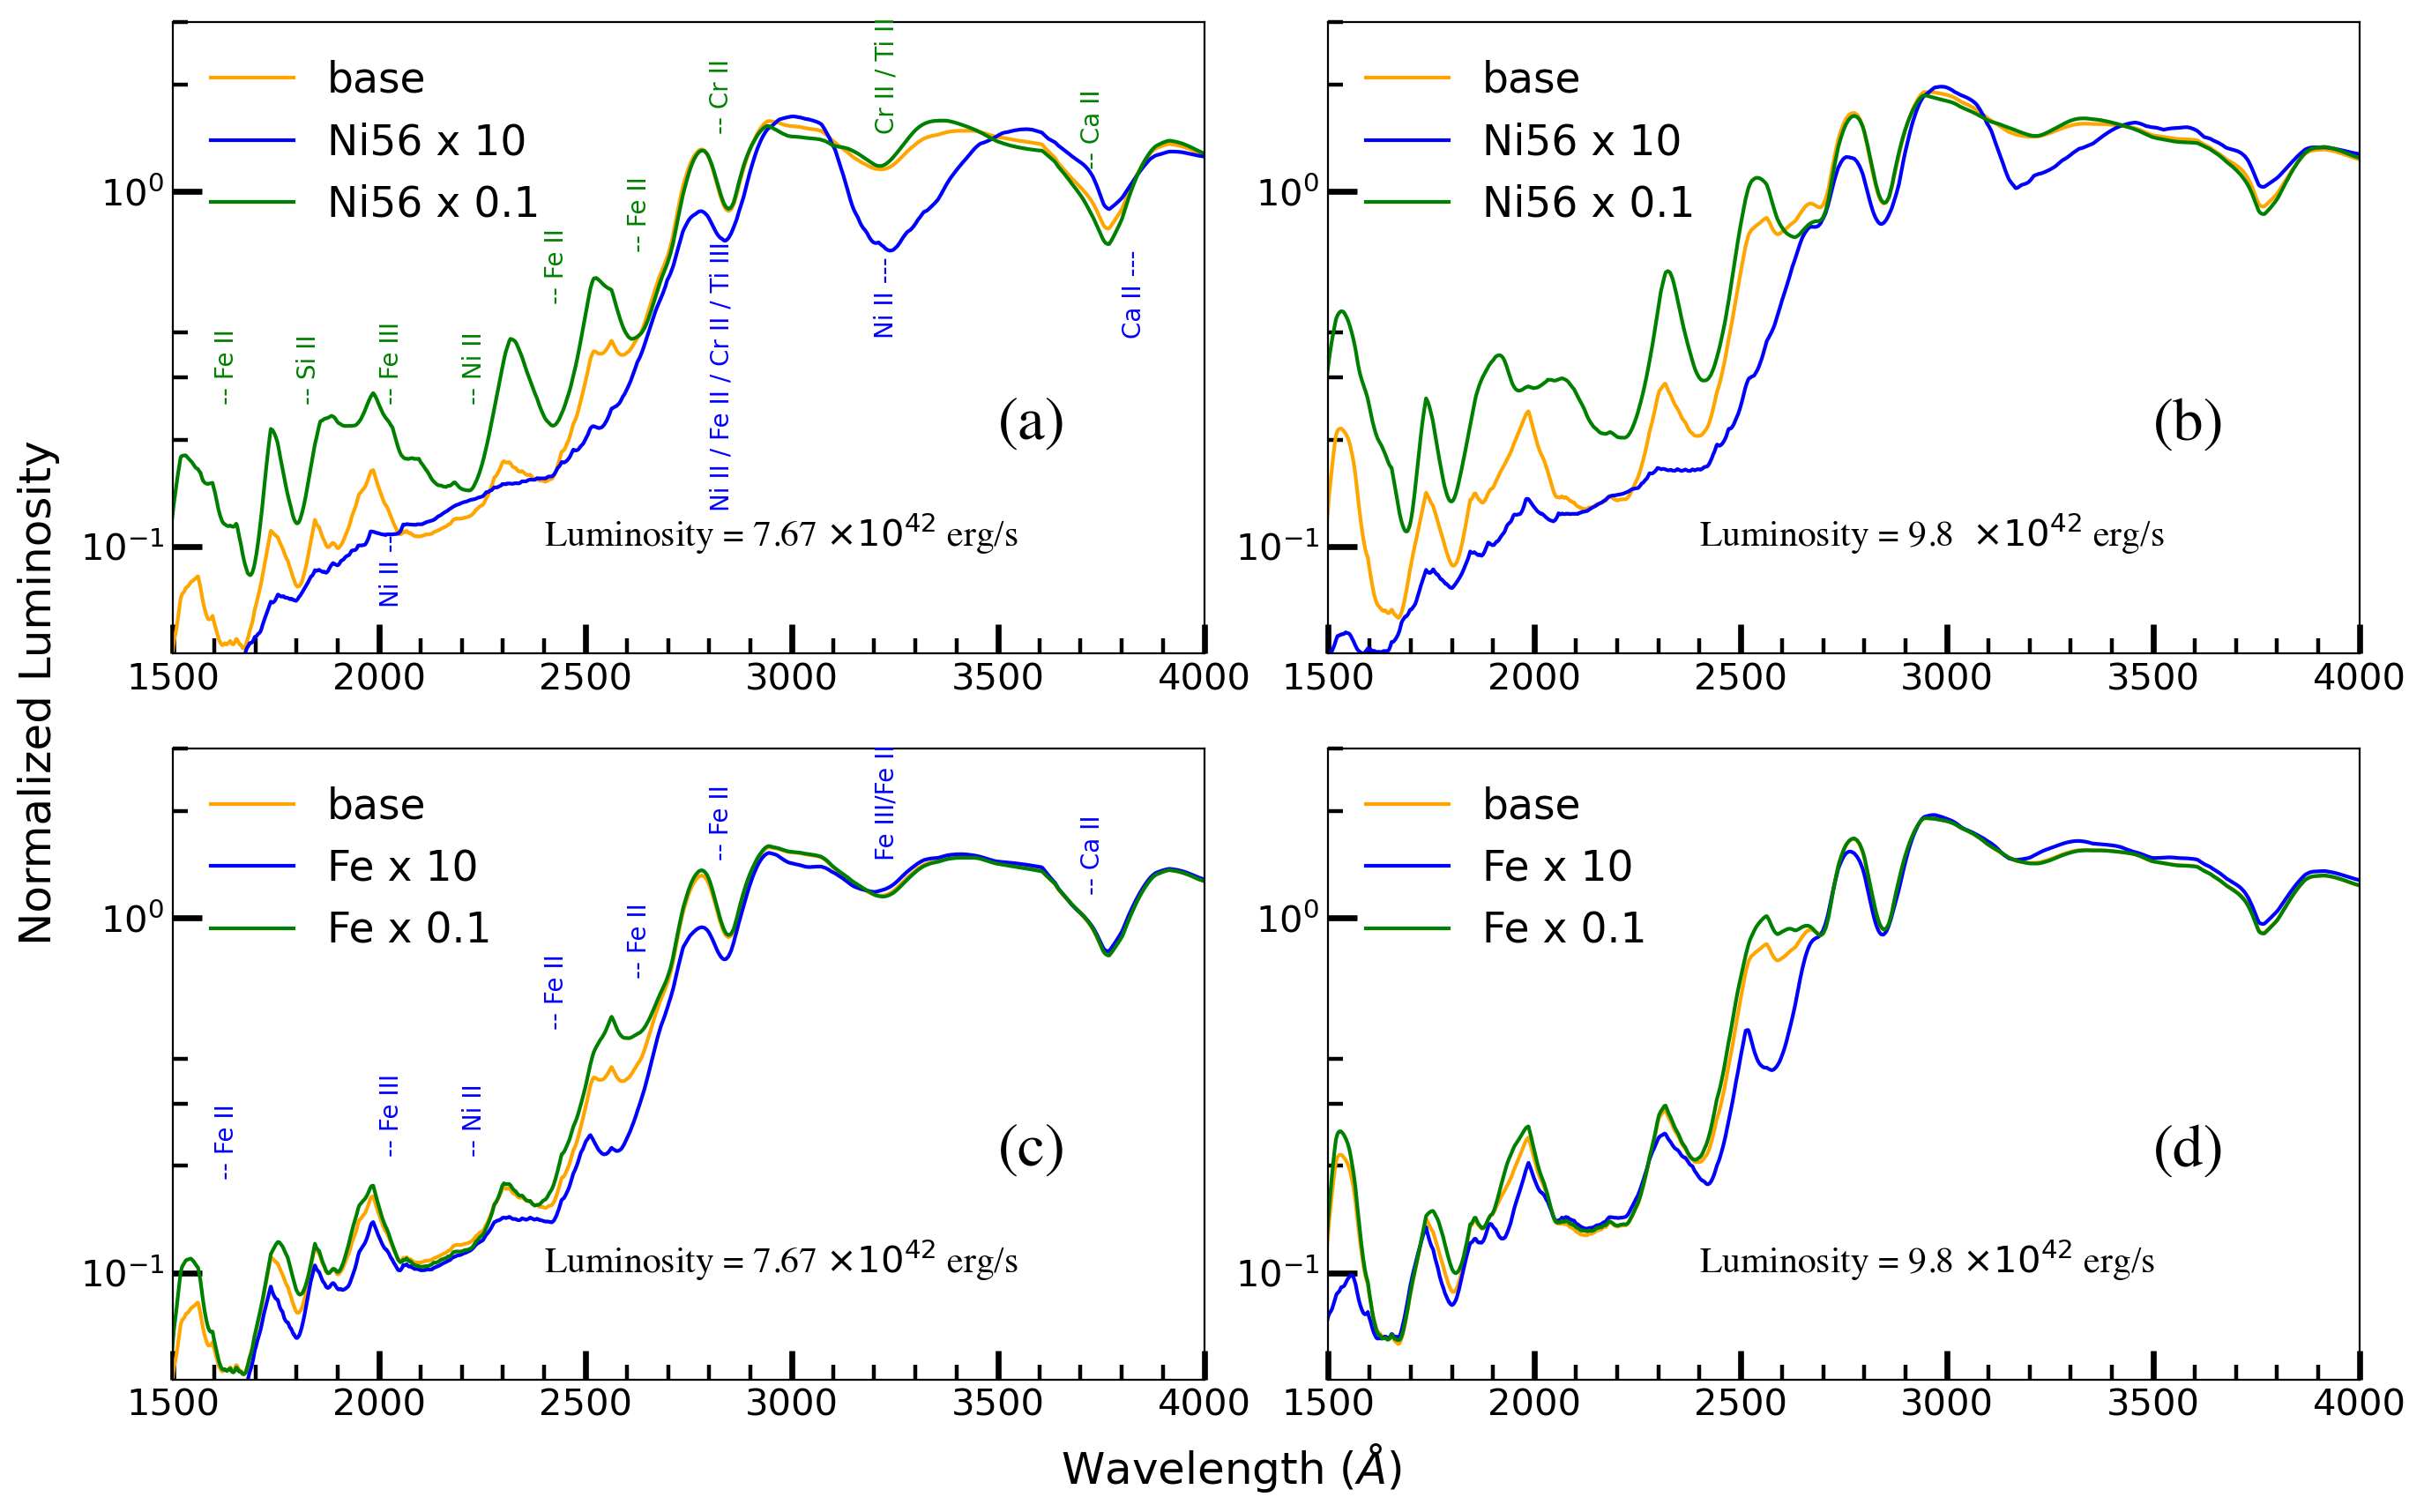

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.subplots_adjust(hspace=0.15)
fig.subplots_adjust(wspace=0.12)

plot_normalized_spectra(low_lum_ni_models, axes[0, 0], legend=True)
axes[0, 0].text(2400, 0.1, r"Luminosity = 7.67 $\times 10^{42}$ erg/s", font="times", fontsize=15)
#axes[0, 0].text(2400, 0.08, r"Time = 12 days", font="times")
#axes[0, 0].text(2400, 0.065, r"$v_{inner}$ = 12000 km/s", font="times")
axes[0, 0].text(3200, 0.4, r"Ni II ---", rotation='vertical', color='blue')
axes[0, 0].text(3800, 0.4, r"Ca II ---", rotation='vertical', color='blue')
axes[0, 0].text(2800, 0.13, r"Ni II / Fe II / Cr II / Ti III", rotation='vertical', color='blue')
axes[0, 0].text(2000, 0.07, r"Ni II --", rotation='vertical', color='blue')


axes[0, 0].text(3700, 1.2, r"-- Ca II", rotation='vertical', color='green')
axes[0, 0].text(3200, 1.5, r"Cr II / Ti II", rotation='vertical', color='green')
axes[0, 0].text(2800, 1.5, r"-- Cr II", rotation="vertical", color='green')
axes[0, 0].text(2600, 0.7, r"-- Fe II", rotation="vertical", color='green')
axes[0, 0].text(2400, 0.5, r"-- Fe II", rotation="vertical", color='green')
axes[0, 0].text(2200, 0.26, r"-- Ni II", rotation="vertical", color='green')
axes[0, 0].text(2000, 0.26, r"-- Fe III", rotation="vertical", color='green')
axes[0, 0].text(1800, 0.26, r"-- Si II", rotation="vertical", color='green')
axes[0, 0].text(1600, 0.26, r"-- Fe II", rotation="vertical", color='green')
#axes[0, 0].axvline(3200)


plot_normalized_spectra(high_lum_ni_models, axes[0, 1], legend=True)
axes[0, 1].text(2400, 0.1, r"Luminosity = 9.8  $\times 10^{42}$ erg/s", font="times", fontsize=15)
#axes[0, 1].text(2400, 0.08, r"Time = 12 days", font="times")
#axes[0, 1].text(2400, 0.065, r"$v_{inner}$ = 12000 km/s", font="times")


plot_normalized_spectra(low_lum_fe_models, axes[1, 0], legend=True)
axes[1, 0].text(2400, 0.1, r"Luminosity = 7.67 $\times 10^{42}$ erg/s", font="times", fontsize=15)
#axes[1, 0].text(2400, 0.08, r"Time = 12 days", font="times")
#axes[1, 0].text(2400, 0.065, r"$v_{inner}$ = 12000 km/s", font="times")
axes[1, 0].text(3700, 1.2, r"-- Ca II", rotation='vertical', color='blue')
axes[1, 0].text(3200, 1.5, r"Fe III/Fe II", rotation='vertical', color='blue')
axes[1, 0].text(2800, 1.5, r"-- Fe II", rotation="vertical", color='blue')
axes[1, 0].text(2600, 0.7, r"-- Fe II", rotation="vertical", color='blue')
axes[1, 0].text(2400, 0.5, r"-- Fe II", rotation="vertical", color='blue')
axes[1, 0].text(2200, 0.22, r"-- Ni II", rotation="vertical", color='blue')
axes[1, 0].text(2000, 0.22, r"-- Fe III", rotation="vertical", color='blue')
#axes[1, 0].text(1800, 0.26, r"-- Si II", rotation="vertical", color='blue')
axes[1, 0].text(1600, 0.19, r"-- Fe II", rotation="vertical", color='blue')

plot_normalized_spectra(high_lum_fe_models, axes[1, 1], legend=True)
axes[1, 1].text(2400, 0.1, r"Luminosity = 9.8 $ \times 10^{42}$ erg/s", font="times", fontsize=15)
#axes[1, 1].text(2400, 0.08, r"Time = 12 days", font="times")
#axes[1, 1].text(2400, 0.065, r"$v_{inner}$ = 12000 km/s", font="times")

# axes[0, 2].plot(all_low_ratio_df['lum'], all_low_ratio_df['ratio_f3025'], 'r*')
# axes[0, 2].text(8.0, 1.45, r'f3025', color='red')
# axes[0, 2].plot(all_low_ratio_df['lum'], all_low_ratio_df['ratio_f2535'], 'ro')
# axes[0, 2].text(8.0, 0.4, r'f2535', color='red')

fig.supxlabel(r'Wavelength ($\AA$)', fontsize=18, y=0.045)
fig.supylabel('Normalized Luminosity', fontsize=18, x=0.07)
#fig.delaxes(axes[1, 2])


# axes[0, 2].plot(all_high_ratio_df['lum'], all_high_ratio_df['ratio_f3025'], 'g*')
# axes[0, 2].text(9.5, 1.70, r'f3025', color='green')
# axes[0, 2].plot(all_high_ratio_df['lum'], all_high_ratio_df['ratio_f2535'], 'go')
# axes[0, 2].text(9.5, 0.6, r'f2535', color='green')
# axes[0, 2].set_xlabel(r'$\rm Luminosity~(\times~10^{42}~erg~s^{-1})$')
# axes[0, 2].set_ylabel(r'$\rm Flux~Ratio$')

axes[0, 0].text(3500, 0.2, r"(a)", fontsize=25, color='black', font="times")
axes[0, 1].text(3500, 0.2, r"(b)", fontsize=25, color='black', font="times")
axes[1, 0].text(3500, 0.2, r"(c)", fontsize=25, color='black', font="times")
axes[1, 1].text(3500, 0.2, r"(d)", fontsize=25, color='black', font="times")
#axes[0, 2].text(8.0,  0.8, r"(e)", fontsize=25, color='black', font="times")

plt.savefig("normalized_luminosity_IGE_mass_fractions.png", dpi=300, bbox_inches="tight")


Available spectra:
tardis_uniform_base_low_luminosity_normal_Ia/spectrum.csv
tardis_uniform_base_normal_Ia/spectrum.csv


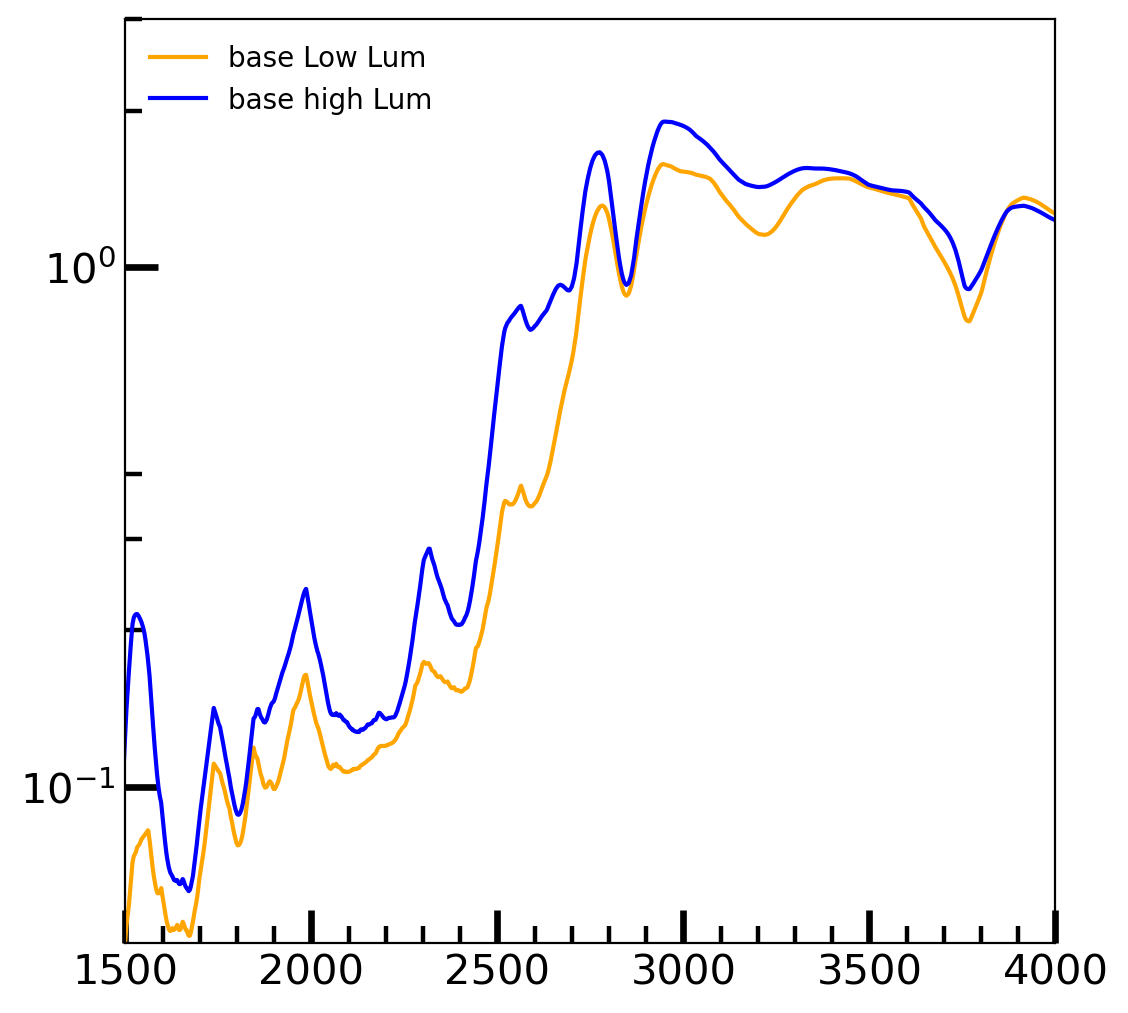

In [13]:
fig, axes = plt.subplots(1, 1, figsize=(6,6))

plot_normalized_spectra(low_high, axes, legend=True)